In [21]:
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import cmaps as cmap 
import scipy 
np.set_printoptions(suppress=True)

def get_zscores(data):
    all_zscores = []
    tempData = data
    mean = tempData.mean(['time'])
    stdd = tempData.std(['time'])

    all_zscores = ((tempData - mean) / stdd)

    all_zscores = xr.DataArray(
        data=all_zscores,
        dims=('time', 'radius', 'theta'),
        coords=dict(
            time=(["time"], data.time.values),
            radius=(["radius"], data.radius.values),
            theta=(["theta"], data.theta.values)
        ))

    return all_zscores

def rectangle(data):
    R, TH = np.meshgrid(data.radius, data.theta, indexing='ij')

    xCoord = R * np.cos(TH)
    yCoord = R * np.sin(TH)

    points = np.column_stack([xCoord.ravel(), yCoord.ravel()])
    values = data.values.ravel()

    Rmax = float(data.radius.max())
    # same resolution as your r-array, but centered
    x = np.linspace(-Rmax, Rmax, data.radius.size)
    y = np.linspace(-Rmax, Rmax, data.radius.size)
    Xt, Yt = np.meshgrid(x, y, indexing='xy')

    print(points.shape, values.shape, Xt.shape, Yt.shape)

    rhXY = scipy.interpolate.griddata(points, values, (Xt, Yt), method='linear')

    return Yt, Xt, rhXY

labelsize = 9
numOfEOFS = 15

In [5]:
fulldataset = xr.open_dataset(r"C:\Users\deela\Downloads\mel1028netcdfv2.nc")
dataset = fulldataset.sel(time = slice(np.datetime64('2025-10-28T18')), radius = slice(0, 200))
print(dataset)

<xarray.Dataset> Size: 347MB
Dimensions:    (time: 1080, radius: 201, theta: 200)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2025-10-28 ... 2025-10-28T17:59:00
  * radius     (radius) int64 2kB 0 1 2 3 4 5 6 ... 194 195 196 197 198 199 200
  * theta      (theta) float64 2kB -3.136 -3.105 -3.073 ... 3.078 3.11 3.142
Data variables:
    data       (time, radius, theta) float64 347MB ...
    latitude   (time) float64 9kB ...
    EyeRad     (time) float64 9kB ...
    EyeTmp     (time) float64 9kB ...
    MinTmpRad  (time) float64 9kB ...
    CDOTmp     (time) float64 9kB ...
    CDORad     (time) float64 9kB ...
    CDOStd     (time) float64 9kB ...
    MinStd     (time) float64 9kB ...
    MaxStd     (time) float64 9kB ...
    longitude  (time) float64 9kB ...


In [6]:
data = dataset['data']#.sel(theta = slice(7 * np.pi / 16, 9 * np.pi / 16))
data = data.diff('time')
data.values = np.nan_to_num(data.values)
fft = np.fft.fft(data, axis = 0)
print(fft.shape)
A = np.abs(fft)
phi = np.angle(fft)

T = data.shape[0]   # 901
dt = 1.0            # minutes
freqs = np.fft.fftfreq(T, d=dt)
periods = np.where(freqs != 0, 1/freqs, np.inf)

valid = freqs > 0

(1079, 201, 200)


C:\Users\deela\AppData\Local\Temp\ipykernel_24420\659078170.py:12: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs != 0, 1/freqs, np.inf)


(537, 201)


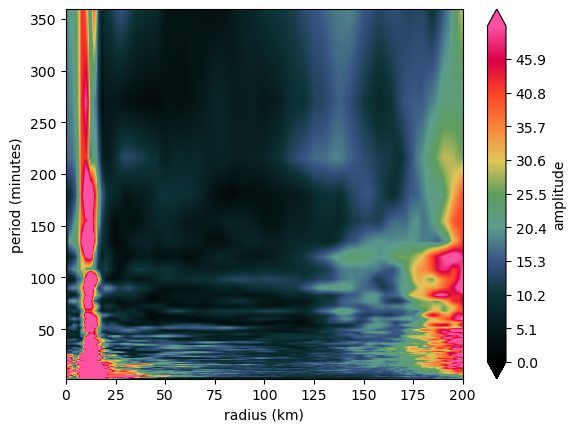

In [8]:
AωT = A[:, :, 40:60].mean(axis=2)  

valid = (freqs > 0) & (periods > 0) & (periods <= 360)

dat = AωT[valid,:]
print(dat.shape)
# dat = (dat - np.nanmin(dat, axis = 0)[np.newaxis, :]) / (np.nanmax(dat, axis = 0)[np.newaxis, :] - np.nanmin(dat, axis = 0)[np.newaxis, :])

plt.figure()
plt.contourf(data.radius, periods[valid], dat, cmap = cmap.probs4(), levels = np.arange(0, 51, .1), extend = 'both')
# plt.yscale('log')
# plt.xlim(1, 25)
# plt.ylim(2, 360)
plt.xlabel("radius (km)")
plt.ylabel("period (minutes)")
plt.colorbar(label="amplitude")
plt.show()

In [9]:
radius = data.radius
temp = data.values
times = data.time.values

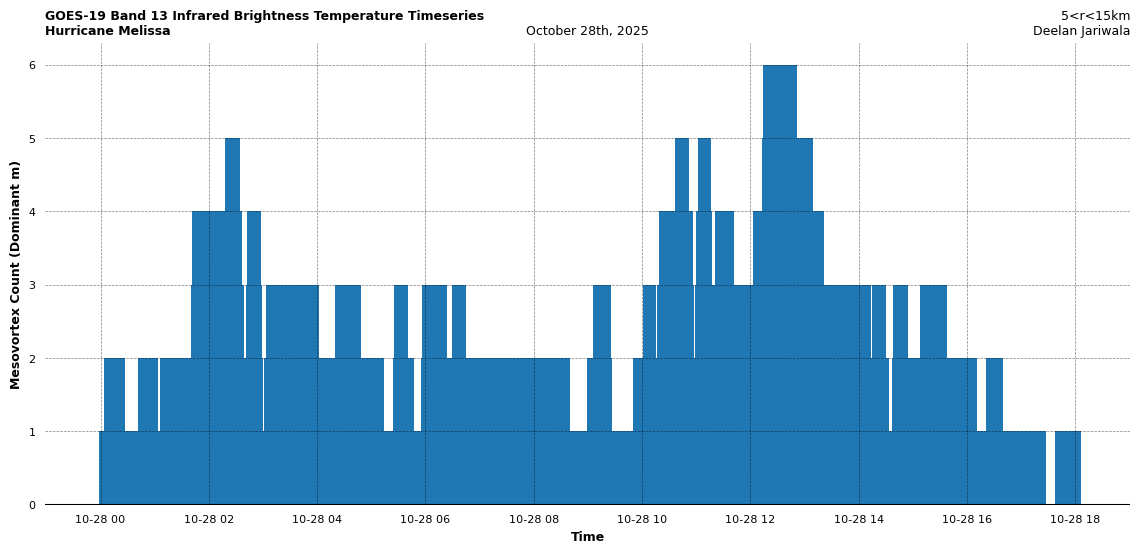

In [45]:
from scipy.ndimage import gaussian_filter1d, gaussian_filter


rmax1 = 5
rmax2 = 15

# Step 1: radial average inside inner core
mask = (rmax1 < radius) & (radius < rmax2) 
core = data[:, mask, :].mean(axis=1).values   # (time, theta)

# Step 3: FFT over theta
fft_theta = np.fft.fft(core, axis=1)          # (time, m)
A = np.abs(fft_theta)

# Step 4: define mode range to search
m_min = 0
m_max = 30   # you can set to 6 if you know mesos <=5
m_range = np.arange(m_min, m_max+1)

# Step 5: argmax in that band
dominant_m_idx = A[:, m_range].argmax(axis=1)
dominant_m = m_range[dominant_m_idx]   # (time,)

# Step 6: plot mesovortex count/time
LABELSIZE = 8
fig = plt.figure(figsize=(14, 6))
ax = plt.axes()

ax.set_frame_on(False)
ax.tick_params(axis='both', labelsize=LABELSIZE, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel(f'Time', weight = 'bold', size = 9)
ax.set_ylabel(f'Mesovortex Count (Dominant m)', weight = 'bold', size = 9)
ax.axhline(color = 'black')

amp = A[np.arange(len(dominant_m_idx)), dominant_m_idx]
# c = ax.scatter(data.time, gaussian_filter1d(dominant_m, sigma = 1), c = amp, linewidth = 2, cmap = cmap.probs4(), vmin = 0, vmax = 200)#, color = 'black')
c = ax.bar(data.time, gaussian_filter1d(dominant_m, sigma = 1), width = np.timedelta64(15, 'm'))
ax.set_title(f'GOES-19 Band 13 Infrared Brightness Temperature Timeseries\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October 28th, 2025', fontsize=9, loc='center') 
ax.set_title(f'{rmax1}<r<{rmax2}km\nDeelan Jariwala', fontsize=9, loc='right') 
plt.savefig(r"C:\Users\deela\Downloads\testHov_wavenum.png", dpi = 400, bbox_inches = 'tight')
# cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Amplitude')
# cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.show()


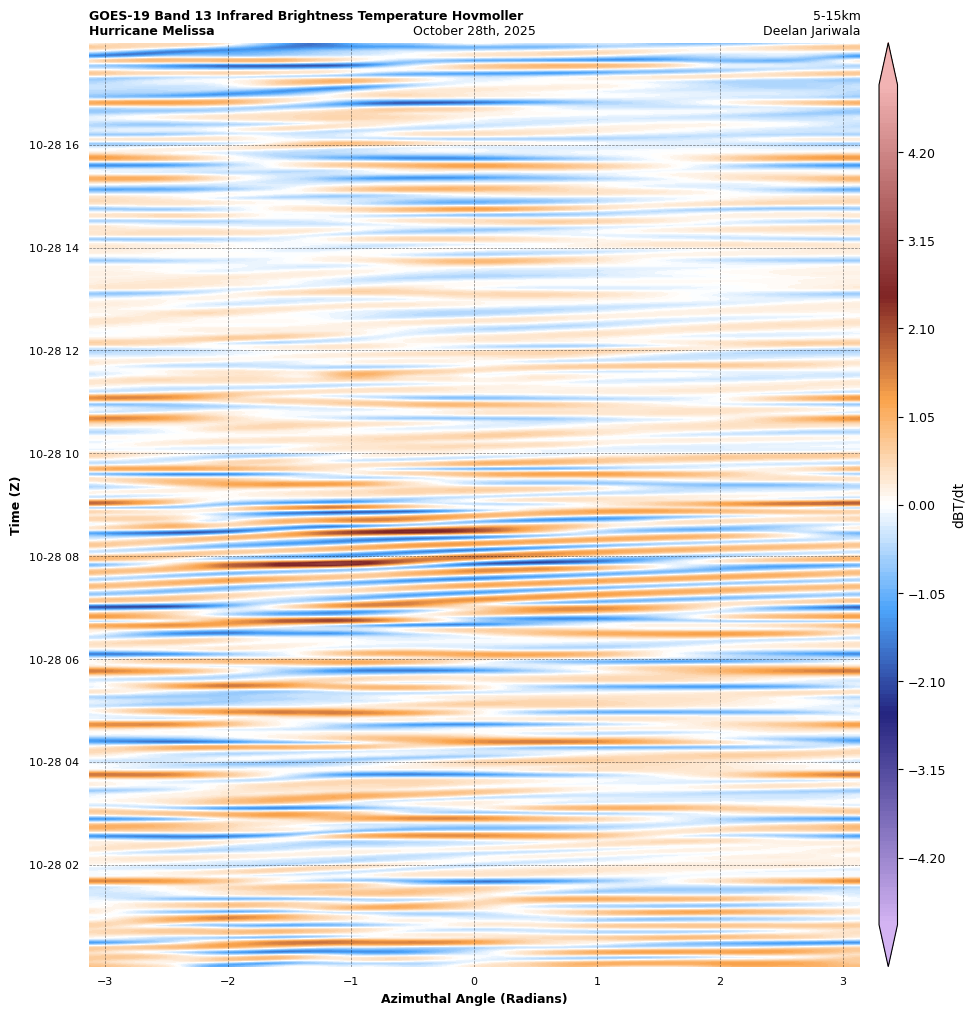

In [46]:
yLabels = [times[x] for x in range(len(times)) if x % 60 == 0]

from scipy.ndimage import gaussian_filter

fig = plt.figure(figsize=(12, 12))

# Add the map and set the extent
ax = plt.axes()
ax.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel('Azimuthal Angle (Radians)', weight = 'bold', size = 9)
ax.set_ylabel('Time (Z)', weight = 'bold', size = 9)
# ax.set_yticks(np.arange(0, len(times), 60))
# ax.set_yticklabels(yLabels)
# ax.set_xlim(0, 25)
# ax.set_ylim(180, 240)

c = plt.contourf(data.theta, data.time, gaussian_filter(core, sigma = 3), cmap = cmp.tempAnoms(), levels = np.arange(-5, 5.05, .05), extend = 'both')
# c = plt.contourf(np.arange(data.theta.values.shape[0]), data.time, gaussian_filter(core, sigma = 3), cmap = cmp.tempAnoms(), levels = np.arange(-5, 5, .05), extend = 'both')

ax.set_title(f'GOES-19 Band 13 Infrared Brightness Temperature Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October 28th, 2025', fontsize=9, loc='center') 
ax.set_title(f'{rmax1}-{rmax2}km\nDeelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'dBT/dt')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.savefig(r"C:\Users\deela\Downloads\testHov.png", dpi = 400, bbox_inches = 'tight')
plt.show()

C:\Users\deela\AppData\Local\Temp\ipykernel_24420\271793327.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 3 Axes> than <Figure size 1400x600 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'dBT/dt')


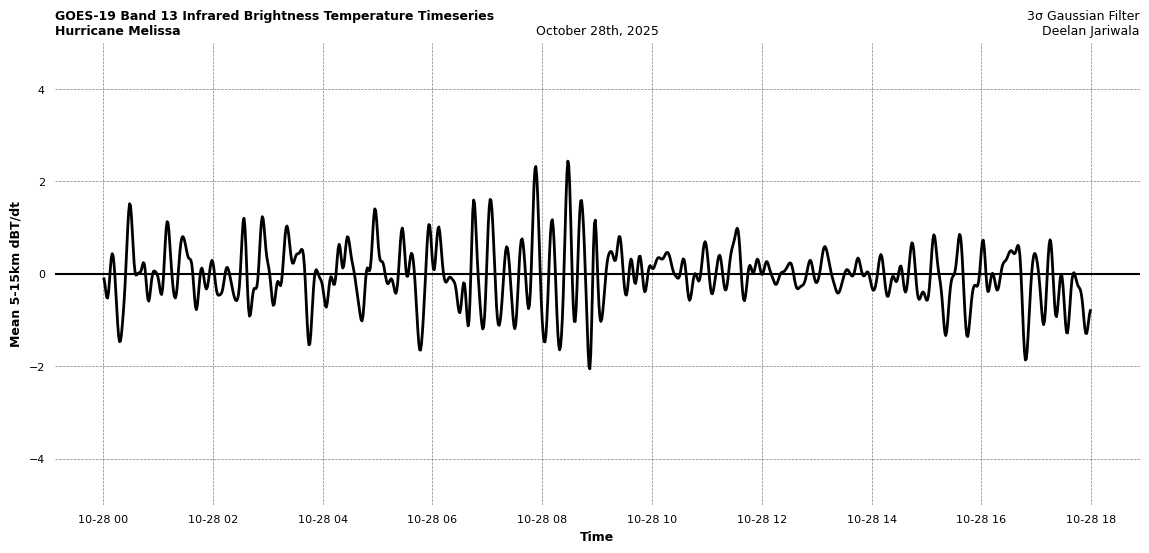

In [47]:
LABELSIZE = 8
fig = plt.figure(figsize=(14, 6))
ax = plt.axes()

ax.set_frame_on(False)
ax.tick_params(axis='both', labelsize=LABELSIZE, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel(f'Time', weight = 'bold', size = 9)
ax.set_ylabel(f'Mean {rmax1}-{rmax2}km dBT/dt', weight = 'bold', size = 9)
ax.set_ylim(-5, 5)

# ax.axvline(color = 'black')
ax.axhline(color = 'black')

# ax.plot(data.time, gaussian_filter1d(core.mean(axis = 1), sigma = 3), linewidth = 2, color = 'black')
ax.plot(data.time, gaussian_filter1d(core[:, 70:80].mean(axis = 1), sigma = 3), linewidth = 2, color = 'black')
    
ax.set_title(f'GOES-19 Band 13 Infrared Brightness Temperature Timeseries\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October 28th, 2025', fontsize=9, loc='center') 
ax.set_title(f'3σ Gaussian Filter\nDeelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'dBT/dt')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.savefig(r"C:\Users\deela\Downloads\testHov_mean.png", dpi = 400, bbox_inches = 'tight')
plt.show()

(1080, 500, 200)


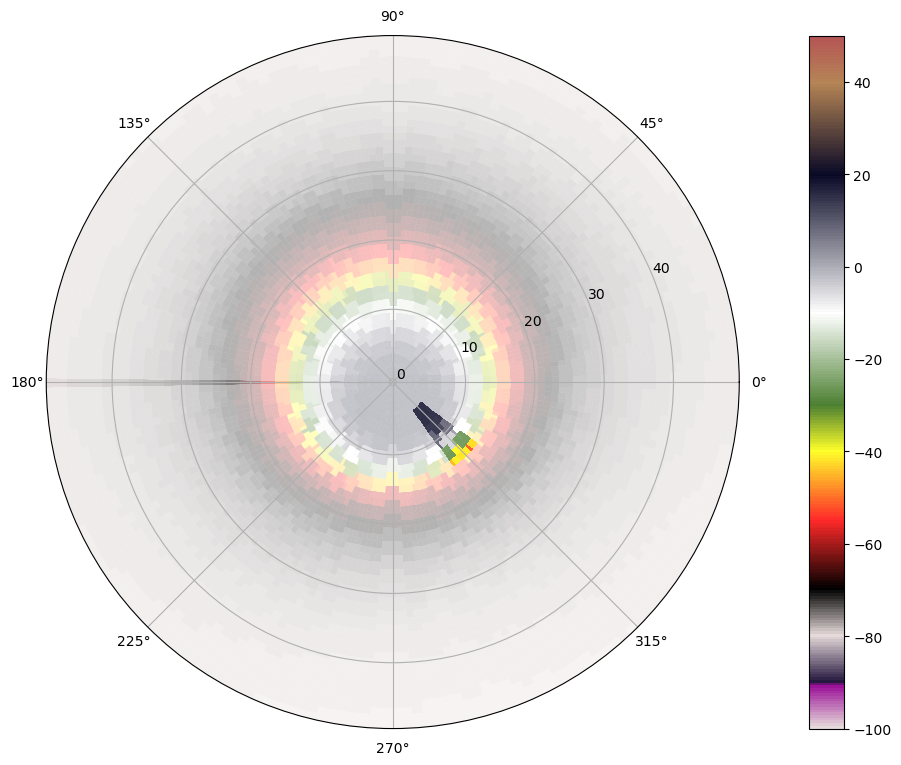

In [341]:
plt.figure(figsize = (18, 9))
plt.subplot(projection = 'polar')
print(fulldataset['data'].values.shape)
plt.pcolormesh(fulldataset.theta, fulldataset.radius[:50], fulldataset['data'].mean('time').values[:50], alpha = 0.3, antialiased=True, vmin = -100, vmax = 50, cmap = cmap)
plt.pcolormesh(fulldataset.theta[70:80], fulldataset.radius[int(rmax1):int(rmax2)], fulldataset['data'].mean('time').values[int(rmax1):int(rmax2), 70:80], vmin = -100, vmax = 50, cmap = cmap, linewidth = 0)
plt.colorbar()
plt.show()

1079 (1079,)
[[-0.04922177]]
0 8


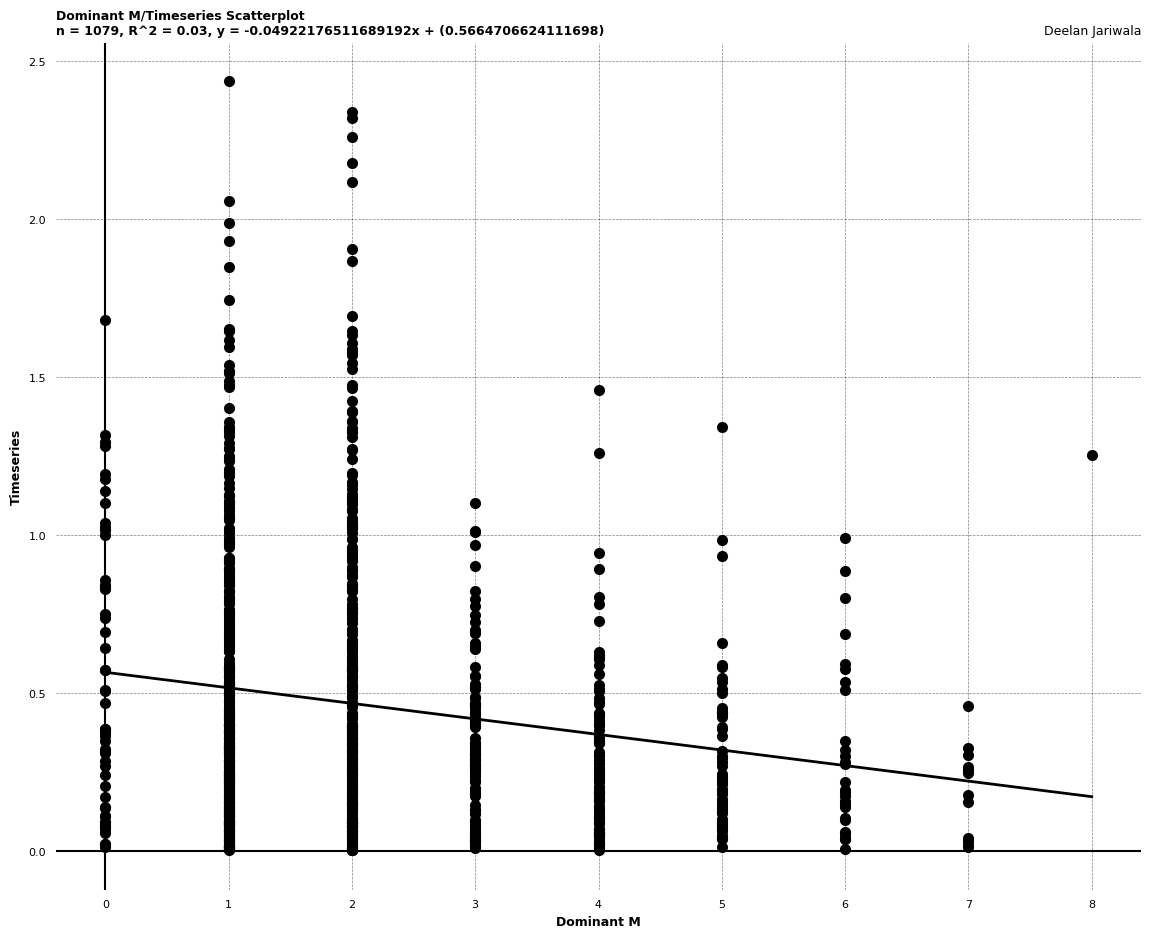

In [373]:
from defaultPlots import scatter 

scatter(['Dominant M', dominant_m], ['Timeseries', np.abs(gaussian_filter1d(core[:, 70:80].mean(axis = 1), sigma = 3))])